In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [3]:
np.random.seed(42)
n = 10000

In [4]:
df = pd.DataFrame({
    'study_hours': np.random.normal(loc=6, scale=2, size=n),
    'sleep_hours': np.random.normal(loc=7, scale=1.5, size=n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float)
})

score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n))

df['result'] = (score > score.median()).astype(int)

In [7]:
df.head()

,study_hours,sleep_hours,attendance_pct,prev_score,stress_level,exercise_days,result
0,6.993428,5.982258,80.224294,35.291420,3.0,2.0,0
1,5.723471,6.541751,79.249854,49.175215,6.0,5.0,1
2,7.295377,6.103928,60.952202,56.194574,4.0,1.0,0
3,9.046060,7.165627,83.693763,67.245034,4.0,6.0,1
4,5.531693,8.795768,52.648760,80.362435,5.0,0.0,1


In [8]:
X = df.drop('result', axis=1)
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

In [11]:
y_train.shape

(7500,)

In [31]:
ada = AdaBoostClassifier(
    # base learner - Decision Stump is the classic choice
    estimator=DecisionTreeClassifier(max_depth=1),
    # Number of boosting rounds
    n_estimators=100,
    # Shrinks the coefficient of each model
    learning_rate=1.0,
    random_state=42)

In [32]:
ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [33]:
y_pred = ada.predict(X_test)

In [34]:
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}")
print("---------------")
print(classification_report(y_test, y_pred))

Accuracy: 85.6
---------------
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1238
           1       0.86      0.85      0.86      1262

    accuracy                           0.86      2500
   macro avg       0.86      0.86      0.86      2500
weighted avg       0.86      0.86      0.86      2500



## Watching Adaboost learn over rounds

D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


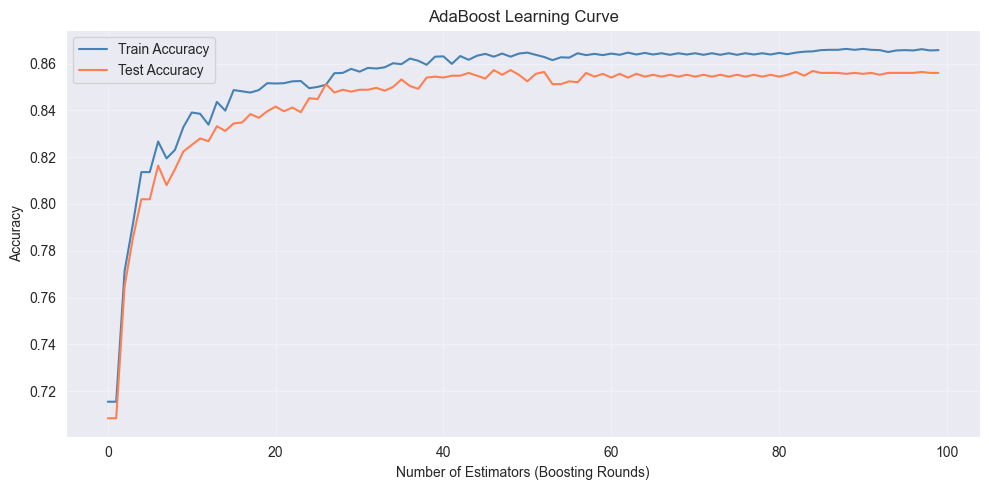

In [21]:
import matplotlib.pyplot as plt

# staged_score gives accuracy after each boosting round
train_scores = list(ada.staged_score(X_train, y_train))
test_scores  = list(ada.staged_score(X_test,  y_test))

plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Train Accuracy', color='steelblue')
plt.plot(test_scores,  label='Test Accuracy',  color='coral')
plt.xlabel("Number of Estimators (Boosting Rounds)")
plt.ylabel("Accuracy")
plt.title("AdaBoost Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# What to look for:
# Both lines rising   → model still learning, add more estimators
# Test line flattens  → good stopping point
# Test line drops     → overfitting, reduce n_estimators

## Hyperparamter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'                  : [50, 100, 200],
    'learning_rate'                 : [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth'          : [1, 2, 3],
    # ↑ double underscore accesses base estimator's params
}

grid = GridSearchCV(
    AdaBoostClassifier(
        estimator    = DecisionTreeClassifier(),
        random_state = 42
    ),
    param_grid,
    cv      = 5,
    scoring = 'accuracy',
    n_jobs  = -1
)

grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best Score :", grid.best_score_)

Best Params: {'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}
Best Score : 0.8637333333333335
